# Module 5 1st Homework — NOAA Buoy (Station 44013)  
**Linear models + regularization + classification + evaluation (A–C)**

In this notebook you’ll apply Module 5 Sections **A–C** to the NOAA buoy dataset (station **44013**):

- **A (Linear models):** OLS baseline regression + coefficient interpretation  
- **A (Regularization):** Ridge + Lasso, tune α on validation  
- **B (Classification):** Logistic regression + (optional) kNN baseline  
- **C (Evaluation):** RMSE/MAE + tail diagnostics, confusion matrix, ROC vs PR, calibration, cost-based thresholds, precision@k

> We are using **random splits** (not temporal splits) for this project notebook so the evaluation mirrors the NYC 311 approach and avoids time-window artifacts during instruction.  
> (In real forecasting you would typically use time-based splits — we’ll discuss that later.)

---

## Deliverable
At the end, write a short **evaluation memo**.



In [64]:
# === Setup ===
import os, json
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, log_loss, brier_score_loss, 
    roc_curve, precision_recall_curve
)
from sklearn.calibration import calibration_curve
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import KNeighborsClassifier

from pandas.api.types import is_numeric_dtype, is_bool_dtype, is_datetime64_any_dtype  

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

SEED = 42
rng = np.random.default_rng(SEED)





## 1) Load curated NOAA data (Module 2 homework artifact)

This project uses the parquet file produced in Module 2 NOAA homework:

- `~/work/homework_2_noaa/data/warehouse/ndbc_curated_44013.parquet`

Expected columns:
`station_id, time_utc, obs_day, obs_hour, dayofweek, is_weekend, wind_high, temp_gap_c, WSPD, GST, WVHT, DPD, APD, PRES, ATMP, WTMP, WDIR`


In [2]:
# Path for HW2
HW2_CURATED_PATH = Path("../work/HW2_NOAA/data/warehouse/ndbc_curated_44013.parquet")

# Find file
print(f"Looking for {HW2_CURATED_PATH}")
if HW2_CURATED_PATH.exists():
    print("found")
else:
    print("not-found")

# Load curated data
def load_curated() -> pd.DataFrame:
    print(HW2_CURATED_PATH)
    if HW2_CURATED_PATH.exists():
        df = pd.read_parquet(HW2_CURATED_PATH)
        df["_source"] = "HW2_3.2_curated_parquet"
        return df

    raise FileNotFoundError(
        "Curated data from Module 2 not found"
    )

df = load_curated()
print(f"Loaded: {df["_source"].iloc[0]}")
print(f"Shape: {df.shape}")
df.head(5)

Looking for ../work/HW2_NOAA/data/warehouse/ndbc_curated_44013.parquet
found
../work/HW2_NOAA/data/warehouse/ndbc_curated_44013.parquet
Loaded: HW2_3.2_curated_parquet
Shape: (6563, 23)


,station_id,time_utc,WDIR,WSPD,GST,WVHT,DPD,APD,MWD,PRES,ATMP,WTMP,DEWP,VIS,PTDY,TIDE,observation_day,observation_hour,dayofweek,is_weekend,wind_high,temp_gap_c,_source
0,44013,2026-02-15 21:30:00+00:00,90.0,3.0,4.0,NaN,NaN,NaN,NaN,1021.9,-0.9,3.0,-10.8,NaN,NaN,NaN,2026-02-15,21,6,1,0,-3.9,HW2_3.2_curated_parquet
1,44013,2026-02-15 21:20:00+00:00,80.0,2.0,4.0,0.8,6.0,4.6,35.0,1021.7,-0.9,3.0,-10.7,NaN,NaN,NaN,2026-02-15,21,6,1,0,-3.9,HW2_3.2_curated_parquet
2,44013,2026-02-15 21:10:00+00:00,80.0,3.0,4.0,NaN,NaN,NaN,NaN,1021.6,-0.9,3.0,-10.7,NaN,NaN,NaN,2026-02-15,21,6,1,0,-3.9,HW2_3.2_curated_parquet
3,44013,2026-02-15 21:00:00+00:00,80.0,3.0,4.0,NaN,NaN,NaN,NaN,1021.4,-1.0,3.0,-10.6,NaN,0.9,NaN,2026-02-15,21,6,1,0,-4.0,HW2_3.2_curated_parquet
4,44013,2026-02-15 20:50:00+00:00,70.0,3.0,4.0,0.8,6.0,4.5,39.0,1021.2,-0.9,3.0,-10.3,NaN,NaN,NaN,2026-02-15,20,6,1,0,-3.9,HW2_3.2_curated_parquet


### Quick schema + missingness snapshot

In [7]:
# Display columns in the dataframe
display(df.dtypes)

# Check for missing columns
required = ["station_id", "time_utc", "observation_day", "observation_hour", "dayofweek", "is_weekend", 
            "wind_high", "temp_gap_c", "WSPD", "GST", "WVHT", "DPD", "APD", "PRES", 
            "ATMP", "WTMP", "WDIR"]

missing = [c for c in required if c not in df.columns]
if missing:
    raise KeyError(f"Missing expected columns: {missing}")

# Missing value summary
missing_summary = pd.DataFrame({
    "pct_missing": (df[required].isna().mean() * 100).round(2)
}).sort_values("pct_missing", ascending=False)
display(missing_summary)



station_id                       object
time_utc            datetime64[ns, UTC]
WDIR                            float64
WSPD                            float64
GST                             float64
WVHT                            float64
DPD                             float64
APD                             float64
MWD                             float64
PRES                            float64
ATMP                            float64
WTMP                            float64
DEWP                            float64
VIS                             float64
PTDY                            float64
TIDE                            float64
observation_day                  object
observation_hour                  int32
dayofweek                         int32
is_weekend                        int64
wind_high                         int64
temp_gap_c                      float64
_source                          object
dtype: object

,pct_missing
DPD,66.75
APD,59.33
WVHT,59.33
temp_gap_c,1.45
WTMP,1.34
WDIR,0.58
PRES,0.34
ATMP,0.23
WSPD,0.14
GST,0.14


## 2) Preprocessing helper

We will build a preprocessing pipeline that:
- imputes missing numeric values (median)
- imputes missing categoricals (most frequent)
- standardizes numerics
- one-hot encodes categoricals
- drops datetimes (unless explicitly engineered upstream)

This prevents “mystery NaNs” in sklearn pipelines.


In [9]:
def build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    """
    X - feature matrix (input variables)
    y - target vector (predict)

    Uses sklearn Pipeline, ColumnTransformer, SimpleImputer, StandardScaler, OneHotEncoder
    Uses pandas api types
    """

    # Sort columns into three buckets by dtype
    num_cols = [c for c in X.columns if is_numeric_dtype(X[c]) or is_bool_dtype(X[c])]
    dt_cols = [c for c in X.columns if is_datetime64_any_dtype(X[c])]
    cat_cols = [c for c in X.columns if (c not in num_cols) and (c not in dt_cols)]

    # Numerical pipeline: fill missing with median, then standardize
    num_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ])

    # Categorical pipeline: fill missing with most frequent, then one-hot encode
    cat_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ])

    # Combine into a single transformer. DateTime columns are droped via remainder=drop
    pre = ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols),
            ("cat", cat_pipe, cat_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    return pre
    

def describe_cols(X: pd.DataFrame) -> tuple[list[str], list[str], list[str]]:
    """
    Inspect columns without running full pre-processor
    Uses pandas api types
    """
    # Sort columns into three buckets by dtype
    num_cols = [c for c in X.columns if is_numeric_dtype(X[c]) or is_bool_dtype(X[c])]
    dt_cols = [c for c in X.columns if is_datetime64_any_dtype(X[c])]
    cat_cols = [c for c in X.columns if (c not in num_cols) and (c not in dt_cols)]
    return num_cols, cat_cols, dt_cols


def split_random(
    X: pd.DataFrame,
    y: pd.Series,
    stratify: pd.Series | None=None,
    seed: int=SEED,
    train: float=0.70,
    val: float=0.15,
    test: float=0.15,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, pd.Series]:
    """
    Split X and y into train, validation and test sets
    Uses sklearn train_test_split()
    """

    # Ensure the three proportions sum to 1.0
    assert abs(train + val + test - 1.0) < 1e-9

    # First split: carve out training set, remainder = val + test
    Xtr, Xtmp, ytr, ytmp = train_test_split(X, y, test_size=(1 - train), random_state=seed, stratify=stratify)

    # Compute remainder fraction
    val_frac_of_tmp = val / (val + test)

    # Second split: divide into val and test
    Xva, Xte, yva, yte = train_test_split(Xtmp, ytmp, test_size=(1 - val_frac_of_tmp), random_state=seed, stratify=(ytmp if stratify is not None else None))

    return Xtr, Xva, Xte, ytr, yva, yte


print("Preprocessing helper functions ready")

Preprocessing helper functions ready


# Part A — Regression (Linear models + regularization)

We will predict a continuous target from weather/ocean variables.

### Regression target (recommended): `WVHT`
`WVHT` = significant wave height (meters).  
We’ll predict it from wind, pressure, temperature, and time-derived features.


In [16]:
# Choose regression target and features
TARGET_REG = "WVHT"

# Drop columns taht are either identifiers or not features
DROP_ALWAYS = {"WVHT", "station_id", "_source", "DEWP", "PTDY", "TIDE", "VIS", "observation_day"}

# Drop raw datetime
DROP_ALWAYS |= {"time_utc"}

# Drop target "cousins"
DROP_ALWAYS |= {"wind_high"}

# Build feature table
y_reg = df[TARGET_REG].astype(float).to_numpy()
X_reg = df.drop(columns=[c for c in DROP_ALWAYS if c in df.columns]).copy()

# Drop rows where target is NaN
mask = ~np.isnan(y_reg)
y_reg = y_reg[mask]
X_reg = X_reg[mask]

# Output
print(f"Regression (X_reg) rows: {X_reg.shape[0]}")
print(f"Regression (X_reg) feature count: {X_reg.shape[1]}")
X_reg.head(3)

Regression (X_reg) rows: 2669
Regression (X_reg) feature count: 13


,WDIR,WSPD,GST,DPD,APD,MWD,PRES,ATMP,WTMP,observation_hour,dayofweek,is_weekend,temp_gap_c
1,80.0,2.0,4.0,6.0,4.6,35.0,1021.7,-0.9,3.0,21,6,1,-3.9
4,70.0,3.0,4.0,6.0,4.5,39.0,1021.2,-0.9,3.0,20,6,1,-3.9
7,60.0,3.0,5.0,5.0,4.4,32.0,1021.0,-1.2,3.0,20,6,1,-4.2


### Randomly split dataset into train/val/test (70/15/15)  
We want a well balanced split (mean should be similar for each split)

In [18]:
# Random split 
Xtr_r, Xva_r, Xte_r, ytr_r, yva_r, yte_r = split_random(X_reg, y_reg, stratify=None)

print(f"Split sizes: {len(ytr_r)}, {len(yva_r)}, {len(yte_r)}")
print(f"Target mean (train/val/test): {float(np.mean(ytr_r))}, {float(np.mean(yva_r))}, {float(np.mean(yte_r))}")
print("Target summary (train):\n")
print(pd.Series(ytr_r).describe())

Split sizes: 1868, 400, 401
Target mean (train/val/test): 1.0626873661670235, 1.1127500000000001, 1.0865336658354117
Target summary (train):

count    1868.000000
mean        1.062687
std         0.711987
min         0.200000
25%         0.600000
50%         0.900000
75%         1.200000
max         4.800000
dtype: float64


In [20]:
# Regression metrics
def rmse(y: np.ndarray, yhat: np.ndarray) -> float:
    return float(np.sqrt(mean_squared_error(y, yhat)))

def regression_report(y_true: np.ndarray, yhat: np.ndarray, label: str="") -> dict:
    """
    Compute raw and absolute errors
    """
    err = y_true - yhat
    abs_err = np.abs(err)
    return {
        "label": label,
        "MAE": float(mean_absolute_error(y_true, yhat)),
        "RMSE": rmse(y_true, yhat),
        "R2": float(r2_score(y_true, yhat)),
        "MedianAbsErr": float(np.median(abs_err)),
        "P90AbsErr": float(np.quantile(abs_err, 0.90)),
        "P95AbsErr": float(np.quantile(abs_err, 0.95)),
    }

# Build preprocessor fit on training features only
pre_r = build_preprocessor(Xtr_r)

# Inspect column buckets without running full preprocessor
num_cols, cat_cols, dt_cols = describe_cols(Xtr_r)
print(f"Regression columns: {len(num_cols)} numeric | {len(cat_cols)} categorical | {len(dt_cols)} datetime dropped")

Regression columns: 13 numeric | 0 categorical | 0 datetime dropped


## A.1 OLS baseline + interpretation

We start with OLS as a baseline:
- fit OLS
- evaluate on validation and test
- extract coefficients (direction + relative importance)

> Interpretation note: With one-hot encoding + scaling, coefficients are comparable in magnitude, but correlated features can still “share credit.”


### Fit OLS

In [21]:
# Build OLS pipeline
ols = Pipeline([("pre", pre_r), ("model", LinearRegression())])

# Fit on training data
ols.fit(Xtr_r, ytr_r)

# Create predictions on validation and test sets
yhat_va = ols.predict(Xva_r)
yhat_te = ols.predict(Xte_r)

### Evaluate on validation and test

In [22]:
# Evaluate: compute regression metrics for both splits
val_ols = regression_report(yva_r, yhat_va, label="ols_val")
test_ols = regression_report(yte_r, yhat_te, label="ols_test")

# Display results as a comparison table
pd.DataFrame([val_ols, test_ols])

,label,MAE,RMSE,R2,MedianAbsErr,P90AbsErr,P95AbsErr
0,ols_val,0.206243,0.296609,0.852626,0.157614,0.374102,0.591476
1,ols_test,0.190157,0.286952,0.853071,0.136575,0.396381,0.510416


<a id="coefficient"></a>
### Extract coefficients (post-preprocessing)

In [23]:
# Extract feature names from the fitted preprocessor
feature_names = pre_r.get_feature_names_out().tolist()

# Extract coefficients from the fitted linear model
coefficients = ols.named_steps["model"].coef_

# Build a DataFrame of feature names and their coefficients
coef_df = (
    pd.DataFrame({"feature": feature_names, "coefficient": coefficients})
      .assign(abs_coef=lambda x: x["coefficient"].abs())
      .sort_values("abs_coef", ascending=False)
      .reset_index(drop=True)
)

display(coef_df)

,feature,coefficient,abs_coef
0,APD,0.464699,0.464699
1,GST,0.184304,0.184304
2,WSPD,0.154184,0.154184
3,dayofweek,-0.113811,0.113811
4,is_weekend,0.097846,0.097846
5,PRES,-0.088866,0.088866
6,WTMP,-0.047694,0.047694
7,ATMP,-0.035669,0.035669
8,WDIR,-0.033191,0.033191
9,DPD,-0.027696,0.027696


## A.2 Ridge + Lasso (tune α on validation)

We tune α on validation (simple grid).  
Then evaluate best model on test.

Why regularize?
- Ridge stabilizes coefficients under collinearity
- Lasso can produce sparse models (feature selection)


### Tune $\alpha$

In [26]:
# Create a list of alphas (tuning constants) to try
alphas = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.1, 1.0, 10.0, 50.0, 200.0]

# Setup
rows = []
best_ridge = None
best_lasso = None

# Ridge - loop over candidate alphas and fit a model for each
for a in alphas: 
    ridge = Pipeline([("pre", pre_r), ("model", Ridge(alpha=a, random_state=SEED))])

    # Fit on training data only
    ridge.fit(Xtr_r, ytr_r)

    # Evaluate on validation set and tag with alpha and model type
    rep = regression_report(yva_r, ridge.predict(Xva_r), label=f"ridge_alpha_{a}_val")
    rep["alpha"] = a
    rep["model"] = "Ridge"
    rows.append(rep)

    # Track the best Ridge model by validation RSME
    if best_ridge is None or rep["RMSE"] < best_ridge["val"]["RMSE"]:
        best_ridge = {"alpha": a, "pipe": ridge, "val": rep}

# Lasso - loop over candidate alphas and fit a model for each
for a in alphas:
    lasso = Pipeline([("pre", pre_r), ("model", Lasso(alpha=a, max_iter=20000, random_state=SEED))])
    
    # Fit on training data only
    lasso.fit(Xtr_r, ytr_r)

    # Evaluate on validation set and tag with alpha and model type
    rep = regression_report(yva_r, lasso.predict(Xva_r), label=f"lasso_alpha_{a}_val")
    rep["alpha"] = a
    rep["model"] = "Lasso"
    rows.append(rep)

    # Track the best Lasso model by validation RSME
    if best_lasso is None or rep["RMSE"] < best_lasso["val"]["RMSE"]:
        best_lasso = {"alpha": a, "pipe": lasso, "val": rep}

# Display all results sorted by RMSE then MAE
val_table = pd.DataFrame(rows).sort_values(["RMSE", "MAE"])
display(val_table)
print(f"Best Ridge on validation: {best_ridge['val']['label']} | alpha: {best_ridge['alpha']} | RMSE: {best_ridge['val']['RMSE']}")
print(f"Best Lasso on validation: {best_lasso['val']['label']} | alpha: {best_lasso['alpha']} | RMSE: {best_lasso['val']['RMSE']}")

,label,MAE,RMSE,R2,MedianAbsErr,P90AbsErr,P95AbsErr,alpha,model
0,ridge_alpha_0.0001_val,0.206243,0.296609,0.852626,0.157614,0.374102,0.591476,0.0001,Ridge
1,ridge_alpha_0.0005_val,0.206243,0.296609,0.852626,0.157614,0.374102,0.591476,0.0005,Ridge
2,ridge_alpha_0.001_val,0.206243,0.296609,0.852626,0.157614,0.374102,0.591476,0.0010,Ridge
3,ridge_alpha_0.005_val,0.206243,0.296609,0.852625,0.157614,0.374101,0.591477,0.0050,Ridge
4,ridge_alpha_0.01_val,0.206243,0.296610,0.852625,0.157615,0.374100,0.591477,0.0100,Ridge
5,ridge_alpha_0.1_val,0.206244,0.296617,0.852618,0.157633,0.374084,0.591484,0.1000,Ridge
10,lasso_alpha_0.0001_val,0.206227,0.296660,0.852575,0.158042,0.373981,0.591636,0.0001,Lasso
6,ridge_alpha_1.0_val,0.206251,0.296691,0.852544,0.157808,0.373919,0.591555,1.0000,Ridge
11,lasso_alpha_0.0005_val,0.206150,0.296881,0.852355,0.157932,0.374097,0.591692,0.0005,Lasso
12,lasso_alpha_0.001_val,0.206065,0.297179,0.852059,0.158828,0.375115,0.591752,0.0010,Lasso


Best Ridge on validation: ridge_alpha_0.0001_val | alpha: 0.0001 | RMSE: 0.2966089506789604
Best Lasso on validation: lasso_alpha_0.0001_val | alpha: 0.0001 | RMSE: 0.2966595589149135


<a id="ols-test"></a>
## OLS, Ridge, Lasso - Evaluate on test

In [27]:
# Retrieve the best fitted pipeline from the tuning step
ridge_best = best_ridge["pipe"]
lasso_best = best_lasso["pipe"]

# Evaluate best Ridge and Lasso on the held-out test set
test_ridge = regression_report(yte_r, ridge_best.predict(Xte_r), label=f"ridge_alpha_{best_ridge['alpha']}_test")
test_lasso = regression_report(yte_r, lasso_best.predict(Xte_r), label=f"lasso_alpha_{best_lasso['alpha']}_test")

# Compare OLS, Ridge, and Lasso side by side, sorted by RMSE
pd.DataFrame([test_ols, test_ridge, test_lasso]).sort_values("RMSE")

,label,MAE,RMSE,R2,MedianAbsErr,P90AbsErr,P95AbsErr
0,ols_test,0.190157,0.286952,0.853071,0.136575,0.396381,0.510416
1,ridge_alpha_0.0001_test,0.190157,0.286952,0.853071,0.136575,0.396381,0.510416
2,lasso_alpha_0.0001_test,0.190099,0.286959,0.853064,0.136596,0.396699,0.510308


<a id="abs_error"></a>
## A.3 Regression diagnostics: residuals + tail risk

We go beyond a single metric:
- residual histogram
- absolute error histogram
- residuals vs predicted (pattern detection)


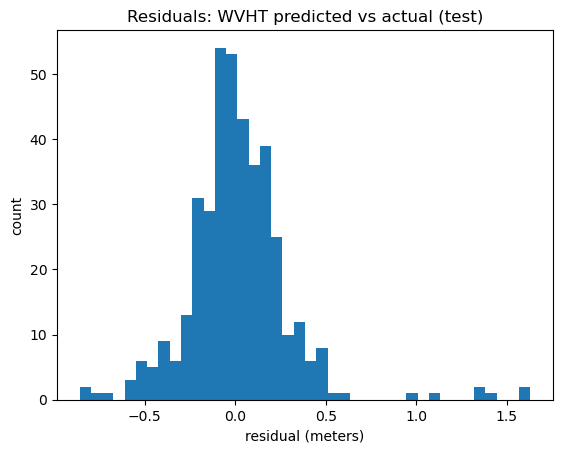

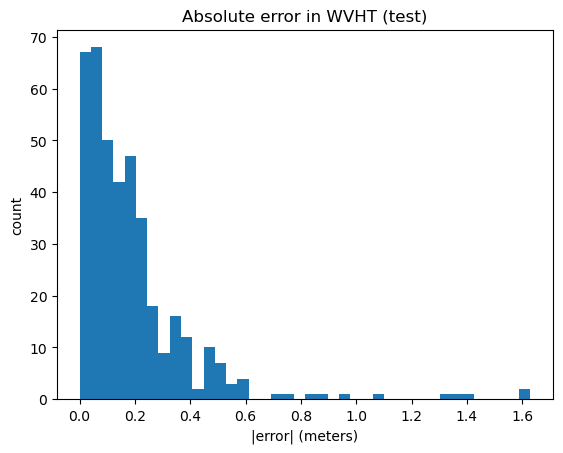

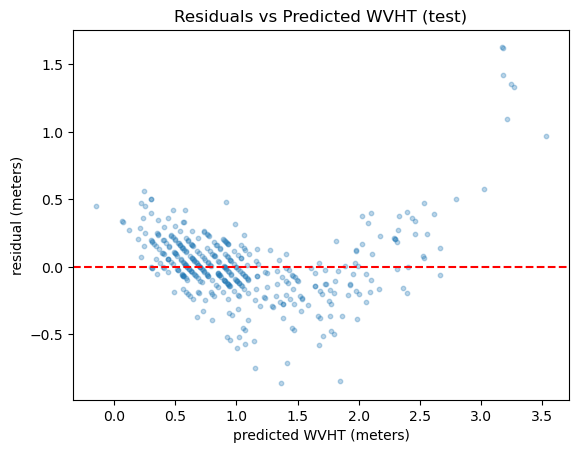

Median abs error: 0.13659589148159046
p90 abs error: 0.39669943984032474
p95 abs error: 0.5103081914921213


In [29]:
# Generate test set predictions from the best model
yhat_te_lasso = lasso_best.predict(Xte_r)

# Compute residuals and absolute errors
residual = yte_r - yhat_te_lasso
abs_err = np.abs(residual)

# Plot residual distribution: check for bias and symmetry
plt.figure()
plt.hist(residual, bins=40)
plt.title("Residuals: WVHT predicted vs actual (test)")
plt.xlabel("residual (meters)")
plt.ylabel("count")
plt.show

# Plot absolute error distribution: check overall spread
plt.figure()
plt.hist(abs_err, bins=40)
plt.title("Absolute error in WVHT (test)")
plt.xlabel("|error| (meters)")
plt.ylabel("count")
plt.show()

# Plot residuals vs predicted: check for patterns or heteroscedasticity
plt.figure()
plt.scatter(yhat_te_lasso, residual, alpha=0.3, s=10)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuals vs Predicted WVHT (test)")
plt.xlabel("predicted WVHT (meters)")
plt.ylabel("residual (meters)")
plt.show()

# Print tail error metrics to quantify worst predictions
print(f"Median abs error: {float(np.median(abs_err))}")       # typical error
print(f"p90 abs error: {float(np.quantile(abs_err, 0.90))}")  # worst 10% threshold
print(f"p95 abs error: {float(np.quantile(abs_err, 0.95))}")  # worst 5% threshold

<a id="slice_rmse"></a>
## A.4 Slice evaluation (regression)

Even with one buoy, performance can vary by:
- hour of day (`obs_hour`)
- weekend vs weekday (`is_weekend`)


In [32]:
# Regression slice: by hour of day (obs_hour) and weekend flag (is_weekend)
df_test_reg = df.loc[Xte_r.index].copy()
df_test_reg["wvht_true"] = yte_r
df_test_reg["wvht_pred"] = yhat_te_lasso
df_test_reg["abs_err"] = np.abs(df_test_reg["wvht_true"] - df_test_reg["wvht_pred"])
df_test_reg["sq_err"] = (df_test_reg["wvht_true"] - df_test_reg["wvht_pred"])**2

def group_reg_metrics(g):
    return pd.Series({
        "n": len(g),
        "MAE": float(g["abs_err"].mean()),
        "RMSE": float(np.sqrt(g["sq_err"].mean())),
        "P90AbsErr": float(np.quantile(g["abs_err"], 0.90)),
    })

# Slice by hour of day
reg_by_hour = df_test_reg.groupby("observation_hour").apply(group_reg_metrics, include_groups=False).sort_values("RMSE", ascending=False)
print("Regression slice by observation_hour:")
display(reg_by_hour)

# Slice by weekend flag
reg_by_weekend = df_test_reg.groupby("is_weekend").apply(group_reg_metrics, include_groups=False).sort_values("RMSE", ascending=False)
print("Regression slice by is_weekend:")
display(reg_by_weekend)

Regression slice by observation_hour:


,n,MAE,RMSE,P90AbsErr
observation_hour,,,,
10,16.0,0.290623,0.543856,0.816617
8,18.0,0.284069,0.429686,0.494191
19,14.0,0.252670,0.427369,0.540355
12,23.0,0.224637,0.415973,0.371361
11,12.0,0.290529,0.352676,0.531309
6,17.0,0.206849,0.322324,0.345323
22,20.0,0.242147,0.318088,0.476257
7,12.0,0.184517,0.308971,0.229336
20,20.0,0.199094,0.272322,0.401512


Regression slice by is_weekend:


,n,MAE,RMSE,P90AbsErr
is_weekend,,,,
0,273.0,0.201198,0.315776,0.422235
1,128.0,0.166426,0.212840,0.374593


# Part B — Classification baselines (Logistic regression + optional kNN)

### Classification target: `wind_high`

We will fit logistic regression on a **SAFE** feature set (to avoid trivial leakage).
Then we’ll evaluate:
- threshold sweep
- ROC vs PR curves
- calibration
- precision@k / lift@k


<a id="base_rate"></a>
### Setup classification

In [39]:
# Choose classification target and features
TARGET_CLF = "wind_high"
if TARGET_CLF not in df.columns:
    raise ValueError(f"Expected {TARGET_CLF} column in curated data.")

# Drop columns that are either identifiers or not features
DROP_ALWAYS_CLF = {"wind_high", "station_id", "_source", "DEWP", "PTDY", "TIDE", "VIS", "observation_day"}

# Drop raw datetime
DROP_ALWAYS_CLF |= {"time_utc"}

# Drop target cousins (WSPD and GST define wind_high - leakage)
DROP_ALWAYS_CLF |= {"WSPD", "GST"}

# Extract target as integer array
y_clf = df[TARGET_CLF].astype(int).to_numpy()

# Build feature table
X_clf = df.drop(columns=[c for c in DROP_ALWAYS_CLF if c in df.columns]).copy()

# Output
print(f"Classification (X_clf) rows: {X_clf.shape[0]}")
print(f"Classification (X_clf) feature count: {X_clf.shape[1]}")
print(f"Positive rate: {float(y_clf.mean())}")
X_clf.head(3)

Classification (X_clf) rows: 6563
Classification (X_clf) feature count: 12
Positive rate: 0.1797958250799939


,WDIR,WVHT,DPD,APD,MWD,PRES,ATMP,WTMP,observation_hour,dayofweek,is_weekend,temp_gap_c
0,90.0,NaN,NaN,NaN,NaN,1021.9,-0.9,3.0,21,6,1,-3.9
1,80.0,0.8,6.0,4.6,35.0,1021.7,-0.9,3.0,21,6,1,-3.9
2,80.0,NaN,NaN,NaN,NaN,1021.6,-0.9,3.0,21,6,1,-3.9


### Split

In [40]:
# 3-way stratified split (stratify ensures positive class appears in all splits
Xtr_c, Xva_c, Xte_c, ytr_c, yva_c, yte_c = split_random(X_clf, y_clf, stratify=y_clf)

# Verify split sizes and that positive rate is preserved
split_summary = pd.DataFrame({
    "split": ["train", "val", "test"],
    "n": [len(ytr_c), len(yva_c), len(yte_c)],
    "positive_rate": [float(ytr_c.mean()), float(yva_c.mean()), float(yte_c.mean())],
})
display(split_summary)

# Fit preprocessor on training data only
pre_c = build_preprocessor(Xtr_c)

,split,n,positive_rate
0,train,4594,0.179800
1,val,984,0.179878
2,test,985,0.179695


### Baseline: Logistic Regression

In [55]:
# Build logistic regression pipeline with balanced class weights
logreg = Pipeline([
    ("pre", pre_c),
    ("model", LogisticRegression(max_iter=3000, solver="lbfgs", class_weight="balanced"))
])

# Fit on training data
logreg.fit(Xtr_c, ytr_c)

# Generate predicted probabilities for the positive class
p_va = logreg.predict_proba(Xva_c)[:,1]
p_te = logreg.predict_proba(Xte_c)[:,1]

# Evaluate on validation split
print(f"Validation ROC-AUC: {float(roc_auc_score(yva_c, p_va))}")
print(f"Validation PR-AUC (avg precision): {float(average_precision_score(yva_c, p_va))}")

Validation ROC-AUC: 0.8705815638586101
Validation PR-AUC (avg precision): 0.5835057835799303


### Baseline: kNN

In [56]:
# Build kNN pipeline
knn = Pipeline([
    ("pre", pre_c),
    ("knn", KNeighborsClassifier(n_neighbors=25, weights="distance"))
])

# Fit on training data
knn.fit(Xtr_c, ytr_c)

# Generate predicted probabilities for the positive class
p_va_knn = knn.predict_proba(Xva_c)[:,1]
p_te_knn = knn.predict_proba(Xte_c)[:,1]

# Evaluate on validation split
print("kNN ROC-AUC (val):", float(roc_auc_score(yva_c, p_va_knn)))
print("kNN PR-AUC (val):", float(average_precision_score(yva_c, p_va_knn)))

kNN ROC-AUC (val): 0.9815631585211321
kNN PR-AUC (val): 0.9232238106840561


## B.1 Threshold sweep (validation)

In [57]:
def eval_at_threshold(y_true: np.ndarray, p: np.ndarray, t: float, label: str = "") -> dict:
    """
    Evaluate classification metrics at a single probability threshold.
    Threshold-independent metrics (roc_auc, avg_precision, log_loss, brier)
    are computed from raw probabilities.
    """
    
    # Convert probabilities into predictions at threshold t
    yhat = (p >= t).astype(int)
    
    # Core classification metrics (from predictions)
    out = {
        "label": label,
        "threshold": float(t),
        "accuracy": float(accuracy_score(y_true, yhat)),
        "precision": float(precision_score(y_true, yhat, zero_division=0)),
        "recall": float(recall_score(y_true, yhat, zero_division=0)),
        "f1": float(f1_score(y_true, yhat, zero_division=0)),
    }
    
    # Threshold-independent metrics (from raw probabilities)
    try:
        out["roc_auc"] = float(roc_auc_score(y_true, p))
    except Exception:
        out["roc_auc"] = float("nan")
    try:
        out["avg_precision"] = float(average_precision_score(y_true, p))
    except Exception:
        out["avg_precision"] = float("nan")
    try:
        out["log_loss"] = float(log_loss(y_true, p))
    except Exception:
        out["log_loss"] = float("nan")
    try:
        out["brier"] = float(brier_score_loss(y_true, p))
    except Exception:
        out["brier"] = float("nan")
    return out


def threshold_sweep(y_true: np.ndarray, p: np.ndarray, thresholds: np.ndarray | None = None) -> pd.DataFrame:
    """
    Evaluate classification metrics across a range of thresholds.
    Returns a DataFrame with one row per threshold.
    """
    # Default: 49 evenly spaced thresholds from 0.02 to 0.98
    if thresholds is None:
        thresholds = np.linspace(0.02, 0.98, 49)
    rows = [eval_at_threshold(y_true, p, float(t)) for t in thresholds]
    return pd.DataFrame(rows)


def confusion_counts(y_true: np.ndarray, p: np.ndarray, t: float) -> tuple[int, int, int, int]:
    """
    Extract raw confusion matrix counts at a given threshold.
    Returns TP, FP, TN, FN.
    """
    yhat = (p >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, yhat).ravel()
    return int(tp), int(fp), int(tn), int(fn)


def per_1000(tp: int, fp: int, tn: int, fn: int) -> dict:
    """
    Normalize confusion counts to a per-1000-events scale.
    """
    n = tp + fp + tn + fn
    s = 1000.0 / n if n else 0.0
    return {
        "FP_per_1000": fp * s,
        "FN_per_1000": fn * s,
        "TP_per_1000": tp * s,
        "TN_per_1000": tn * s,
    }

### Logistic Regression threshold sweep on validation

In [58]:
# Run threshold sweep on validation probabilities
sweep_logreg = threshold_sweep(yva_c, p_va)

# Strategy 1: pick threshold that maximizes F1
best_f1_logreg = sweep_logreg.sort_values("f1", ascending=False).iloc[0]
t_f1_logreg = float(best_f1_logreg["threshold"])

# Strategy 2: pick highest precision among thresholds with recall >= 80%
RECALL_MIN = 0.80
eligible_logreg = sweep_logreg[sweep_logreg["recall"] >= RECALL_MIN]
t_recall_logreg = float(eligible_logreg.sort_values("precision", ascending=False).iloc[0]["threshold"]) if len(eligible_logreg) else t_f1_logreg

print(f"LogReg best-F1 threshold: {t_f1_logreg} | val F1: {float(best_f1_logreg['f1'])}")
print(f"LogReg recall >= {RECALL_MIN:.2f}, threshold: {t_recall_logreg}")

# Diplay top 10 thresholds ranked by F1
display(sweep_logreg.sort_values("f1", ascending=False).head(10))

LogReg best-F1 threshold: 0.7000000000000001 | val F1: 0.592391304347826
LogReg recall >= 0.80, threshold: 0.44


,label,threshold,accuracy,precision,recall,f1,roc_auc,avg_precision,log_loss,brier
34,,0.70,0.847561,0.570681,0.615819,0.592391,0.870582,0.583506,0.461406,0.149094
33,,0.68,0.837398,0.541463,0.627119,0.581152,0.870582,0.583506,0.461406,0.149094
35,,0.72,0.852642,0.596386,0.559322,0.577259,0.870582,0.583506,0.461406,0.149094
32,,0.66,0.825203,0.511312,0.638418,0.567839,0.870582,0.583506,0.461406,0.149094
31,,0.64,0.819106,0.497854,0.655367,0.565854,0.870582,0.583506,0.461406,0.149094
30,,0.62,0.814024,0.487395,0.655367,0.559036,0.870582,0.583506,0.461406,0.149094
29,,0.60,0.804878,0.470817,0.683616,0.557604,0.870582,0.583506,0.461406,0.149094
24,,0.50,0.778455,0.434921,0.774011,0.556911,0.870582,0.583506,0.461406,0.149094
28,,0.58,0.798780,0.460967,0.700565,0.556054,0.870582,0.583506,0.461406,0.149094
36,,0.74,0.851626,0.602649,0.514124,0.554878,0.870582,0.583506,0.461406,0.149094


### kNN threshold sweep on validation

In [59]:
# Run threshold sweep on validation probabilities
sweep_knn = threshold_sweep(yva_c, p_va_knn)

# Strategy 1: pick threshold that maximizes F1
best_f1_knn = sweep_knn.sort_values("f1", ascending=False).iloc[0]
t_f1_knn = float(best_f1_knn["threshold"])

# Strategy 2: pick highest precision among thresholds with recall >= 80%
eligible_knn = sweep_knn[sweep_knn["recall"] >= RECALL_MIN]
t_recall_knn = float(eligible_knn.sort_values("precision", ascending=False).iloc[0]["threshold"]) if len(eligible_knn) else t_f1_knn

print(f"kNN best-F1 threshold: {t_f1_knn} | val F1: {float(best_f1_knn['f1'])}")
print(f"kNN recall >= {RECALL_MIN:.2f}, threshold: {t_recall_knn}")

# Display top 10 ranked by F1
display(sweep_knn.sort_values("f1", ascending=False).head(10))

kNN best-F1 threshold: 0.44 | val F1: 0.9014084507042254
kNN recall >= 0.80, threshold: 0.52


,label,threshold,accuracy,precision,recall,f1,roc_auc,avg_precision,log_loss,brier
21,,0.44,0.964431,0.898876,0.903955,0.901408,0.981563,0.923224,0.221453,0.035068
20,,0.42,0.963415,0.889503,0.909605,0.899441,0.981563,0.923224,0.221453,0.035068
22,,0.46,0.963415,0.898305,0.898305,0.898305,0.981563,0.923224,0.221453,0.035068
19,,0.40,0.962398,0.884615,0.909605,0.896936,0.981563,0.923224,0.221453,0.035068
17,,0.36,0.959350,0.862434,0.920904,0.890710,0.981563,0.923224,0.221453,0.035068
18,,0.38,0.958333,0.865591,0.909605,0.887052,0.981563,0.923224,0.221453,0.035068
15,,0.32,0.954268,0.823529,0.949153,0.881890,0.981563,0.923224,0.221453,0.035068
16,,0.34,0.955285,0.844560,0.920904,0.881081,0.981563,0.923224,0.221453,0.035068
14,,0.30,0.953252,0.819512,0.949153,0.879581,0.981563,0.923224,0.221453,0.035068
13,,0.28,0.952236,0.812500,0.954802,0.877922,0.981563,0.923224,0.221453,0.035068


### Evaluate on test set

In [60]:
def report_with_counts(y_true: np.ndarray, p: np.ndarray, t: float, label: str) -> dict:
    """
    Extend eval_at_threshold with raw confusion matrix counts and per-1000 rates.
    Gives both metric scores and operational counts.
    """
    # Compute standard classification metrics at threshold t
    rep = eval_at_threshold(y_true, p, t, label=label)
    # Add raw confusion matrix counts (TP, FP, TN, FN)
    tp, fp, tn, fn = confusion_counts(y_true, p, t)
    rep.update({"TP": tp, "FP": fp, "TN": tn, "FN": fn})
    # Add per-1000 normalized rates
    rep.update(per_1000(tp, fp, tn, fn))
    return rep

# Evaluate logistic regression on test set using both threshold policies
test_logreg_f1     = report_with_counts(yte_c, p_te, t_f1_logreg, "logreg_test_best_f1")
test_logreg_recall = report_with_counts(yte_c, p_te, t_recall_logreg, "logreg_test_recall_policy")

# Evaluate kNN on test set using both threshold policies
test_knn_f1     = report_with_counts(yte_c, p_te_knn, t_f1_knn, "knn_test_best_f1")
test_knn_recall = report_with_counts(yte_c, p_te_knn, t_recall_knn, "knn_test_recall_policy")

# Display side by side
pd.DataFrame([test_logreg_f1, test_logreg_recall, test_knn_f1, test_knn_recall])[[
    "label", "threshold", "precision", "recall", "f1",
    "roc_auc", "avg_precision",
    "FP_per_1000", "FN_per_1000",
    "log_loss", "brier"
]]

,label,threshold,precision,recall,f1,roc_auc,avg_precision,FP_per_1000,FN_per_1000,log_loss,brier
0,logreg_test_best_f1,0.70,0.509259,0.621469,0.559796,0.863071,0.577940,107.614213,68.020305,0.479829,0.159073
1,logreg_test_recall_policy,0.44,0.395349,0.864407,0.542553,0.863071,0.577940,237.563452,24.365482,0.479829,0.159073
2,knn_test_best_f1,0.44,0.850829,0.870056,0.860335,0.980967,0.897287,27.411168,23.350254,0.264749,0.037800
3,knn_test_recall_policy,0.52,0.902439,0.836158,0.868035,0.980967,0.897287,16.243655,29.441624,0.264749,0.037800


<a id="roc_vs_pr"></a>
## B.2 ROC vs PR curves (test)

LogReg ROC-AUC: 0.8630712647535941
LogReg PR-AUC (avg precision): 0.57794041113253

kNN ROC-AUC: 0.9809671645130615
kNN PR-AUC (avg precision): 0.8972874353300329


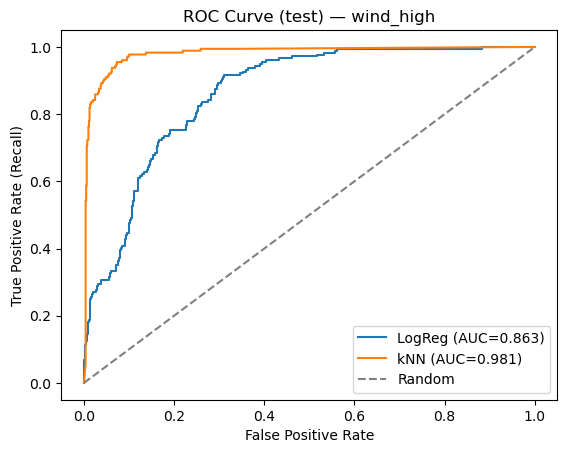

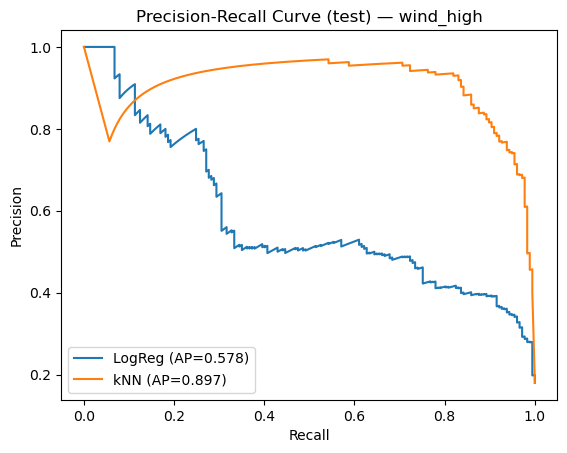

In [63]:
# Compute ROC curves for both models
fpr_logreg, tpr_logreg, _ = roc_curve(yte_c, p_te)
fpr_knn, tpr_knn, _ = roc_curve(yte_c, p_te_knn)

# Compute PR curves for both models
prec_logreg, rec_logreg, _ = precision_recall_curve(yte_c, p_te)
prec_knn, rec_knn, _ = precision_recall_curve(yte_c, p_te_knn)

# Summary of ranking metrics for both models on test set
print(f"LogReg ROC-AUC: {float(roc_auc_score(yte_c, p_te))}")
print(f"LogReg PR-AUC (avg precision): {float(average_precision_score(yte_c, p_te))}")
print()
print(f"kNN ROC-AUC: {float(roc_auc_score(yte_c, p_te_knn))}")
print(f"kNN PR-AUC (avg precision): {float(average_precision_score(yte_c, p_te_knn))}")

# ROC curves
plt.figure()
plt.plot(fpr_logreg, tpr_logreg, label=f"LogReg (AUC={float(roc_auc_score(yte_c, p_te)):.3f})")
plt.plot(fpr_knn, tpr_knn, label=f"kNN (AUC={float(roc_auc_score(yte_c, p_te_knn)):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
plt.title("ROC Curve (test) — wind_high")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.legend()
plt.show()

# PR curves
plt.figure()
plt.plot(rec_logreg, prec_logreg, label=f"LogReg (AP={float(average_precision_score(yte_c, p_te)):.3f})")
plt.plot(rec_knn, prec_knn, label=f"kNN (AP={float(average_precision_score(yte_c, p_te_knn)):.3f})")
plt.title("Precision-Recall Curve (test) — wind_high")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

<a id="calibration"></a>
## B.3 Calibration (test)

LogReg Brier score: 0.15907280170917257
LogReg Log loss   : 0.47982922244003545

kNN Brier score: 0.03779961203212679
kNN Log loss   : 0.2647493512278381


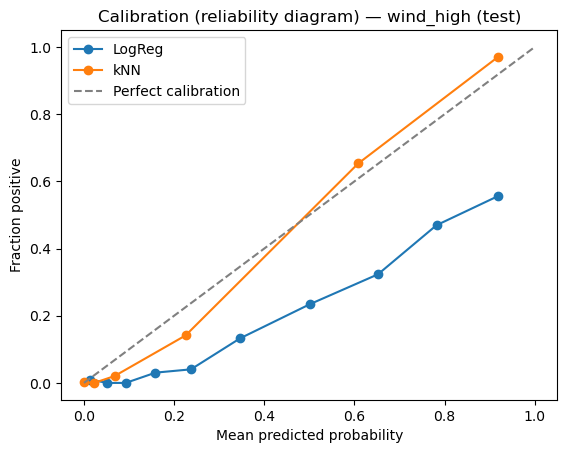

In [65]:
# Calibration curves for both models on test set
prob_true_logreg, prob_pred_logreg = calibration_curve(yte_c, p_te, n_bins=10, strategy="quantile")
prob_true_knn, prob_pred_knn = calibration_curve(yte_c, p_te_knn, n_bins=10, strategy="quantile")

# Calibration metrics
print("LogReg Brier score:", float(brier_score_loss(yte_c, p_te)))
print("LogReg Log loss   :", float(log_loss(yte_c, p_te)))
print()
print("kNN Brier score:", float(brier_score_loss(yte_c, p_te_knn)))
print("kNN Log loss   :", float(log_loss(yte_c, p_te_knn)))

# Plot both on the same figure for comparison
plt.figure()
plt.plot(prob_pred_logreg, prob_true_logreg, marker="o", label="LogReg")
plt.plot(prob_pred_knn, prob_true_knn, marker="o", label="kNN")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
plt.title("Calibration (reliability diagram) — wind_high (test)")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction positive")
plt.legend()
plt.show()



<a id="precision_k"></a>
## B.4 Precision@k / Lift@k (ranking evaluation)

In [66]:
def precision_recall_lift_at_k(y_true: np.ndarray, p: np.ndarray, k: int) -> dict:
    """
    Evaluate a probabilistic classifier as a ranking system.
    """
    y_true = np.asarray(y_true).astype(int)
    p = np.asarray(p).astype(float)

    # Cap k at dataset size
    if k <= 0:
        raise ValueError("k must be positive")
    k = min(k, len(y_true))
    
    # Base rate = fraction of positives in the full test set
    base_rate = float(y_true.mean())
    total_pos = int(y_true.sum())

    # Rank by predicted probability (descending)
    idx = np.argsort(p)[::-1]
    topk = idx[:k]
    pos_topk = int(y_true[topk].sum())

    # preccision@k: of the top k flagged, what fraction are truly positive?    
    prec_k = pos_topk / k

    # recall@k: of all true positives, what fraction was caught in top k
    rec_k = pos_topk / total_pos if total_pos > 0 else 0.0

    # lift@k: how much better than random? (1.0 = no better)
    lift_k = (prec_k / base_rate) if base_rate > 0 else np.nan

    return {
        "k": k,
        "model": None,  # filled below
        "base_rate": base_rate,
        "positives_total": total_pos,
        "positives_in_topk": pos_topk,
        "precision_at_k": prec_k,
        "recall_at_k": rec_k,
        "lift_at_k": lift_k,
    }

# Choose k values relative to test set size
ks = [25, 50, 100, 200, 300]

rows = []
for k in ks:
    
    # Logistic regression
    row_logreg = precision_recall_lift_at_k(yte_c, p_te, k)
    row_logreg["model"] = "LogReg"
    rows.append(row_logreg)
    
    # kNN
    row_knn = precision_recall_lift_at_k(yte_c, p_te_knn, k)
    row_knn["model"] = "kNN"
    rows.append(row_knn)

pd.DataFrame(rows).sort_values(["k", "model"])

,k,model,base_rate,positives_total,positives_in_topk,precision_at_k,recall_at_k,lift_at_k
0,25,LogReg,0.179695,177,21,0.840000,0.118644,4.674576
1,25,kNN,0.179695,177,22,0.880000,0.124294,4.897175
2,50,LogReg,0.179695,177,39,0.780000,0.220339,4.340678
3,50,kNN,0.179695,177,47,0.940000,0.265537,5.231073
4,100,LogReg,0.179695,177,56,0.560000,0.316384,3.116384
5,100,kNN,0.179695,177,96,0.960000,0.542373,5.342373
6,200,LogReg,0.179695,177,104,0.520000,0.587571,2.893785
7,200,kNN,0.179695,177,161,0.805000,0.909605,4.479802
8,300,LogReg,0.179695,177,133,0.443333,0.751412,2.467137
9,300,kNN,0.179695,177,174,0.580000,0.983051,3.227684


# Deliverable: Evaluation memo

Write **12–16 bullets** with real values from your outputs.

### Regression
1) Target (WVHT) and why it matters  
2) Your split protocol (random)  
3) OLS vs best regularized model (MAE/RMSE/R²)  
4) Tail risk: report P90 or P95 absolute error  
5) Residual diagnosis: any pattern? any heteroskedasticity?  
6) Slice with worst RMSE (hour or weekend) and possible explanation  
7) 1–2 feature interpretations from coefficients (direction + why plausible)

### Classification
8) Target (`wind_high`) and base rate  
9) Threshold policy used (best-F1) and why  
10) ROC-AUC vs PR-AUC — what does this say under imbalance?  
11) Calibration: do probabilities mean what they say?  
12) precision@k: if you can only review k=100 cases, what precision/lift do you get?  
13) One improvement you’d try next (feature engineering, label definition, monitoring)



## My Evaluation Memo  

### Regression
1. The target was **WVHT**. We are attempting to predict the wave height given the other dataset quantities
2. We chose to split **randomly** as opposed to temporaly. This was chosen to avoid time-window artifacts
3. The OLS, Lasso, and Ridge all performed very similarly [(A.2)](#ols-test). MAE (differ by 0.0001), RMSE (differ by 0.000007), and R$^2$ (differ by 0.00001). We went forward with Lasso but could have used any of them.
4. The model has a p90=0.397 and p95=0.510 [(A.3)](#abs_error). This shows that in the tail cases, the model can be off by as much as ~40-50 cm.
5. For residual diagnosis, the model displays a **funnel shape** [(A.3)](#abs_error), where at low wave heights the residuals were clustered around zero, but as the wave height increased, the residuals spread out wider and wider. This is heteroscedasticity, where the error variance grows with the predicted value.
6. Hour observation slice 10 had the worst RMSE=0.543856 [(A.4)](#slice_rmse). There were 16 rows as part of this slice. I think we would need to perform more analysis to determine if this outcome is meaningful. We need to determine if time of day has any impact on wave height.
7. From the coefficient table [(A.1)](#coefficient), ADP has the largest positive coefficient (0.465), followed by GST (0.184) and WSPD (0.154). This shows that longer average wave periods (ADP) are strongly associated with higher wave heights. While wind gust speed (GST) and wind speed (WSPD) also play a significant role in wave height

### Classification
8. The target was **wind_high,** and we are attempting to predict if there will be high winds given other dataset quantities. The base rate is ~ 0.1798 [(B.1)](#base_rate)
9. We used threshold policy **best-F1** as it provides a balanced threshold. We are not prioritizing precision or recall.
10. ROC vs. PR [(B.2)](#roc_vs_pr) shows two different things depending on the model used. For logistic regression, ROC=0.863 and PR=0.578 show that the model's actual precision on high wind events is weak. For kNN, ROC=0.981 and PR=0.897, showing that the model's performance is quite strong.
11. The calibration results [(B.3)](#calibration) show kNN (Brier=0.038) is well calibrated while logistic regression (Brier=0.159) is not. This shows that kNN's predicted probabilities are more trustworthy.
12. Looking at k=100 for precision@k [(B.4)](#precision_k), we see that logistic regression has a precision@k=0.56 and kNN has a precision@k=0.96. Another confirmation that kNN outperforms logistic regression
13. One improvement to try next would be to see how the feature PRES relates to high wind speed.

